# CS5788 Final Project Demo

This notebook demonstrates the code pipeline and main outputs for **A Language Study of the Platonic Representation Hypothesis**

The main implementation is in `src/` and `scripts/`. This notebook only loads the generated results and shows the figures used in the report

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

In [2]:
ROOT = Path("..").resolve()
METRICS_DIR = ROOT / "outputs" / "metrics"
FIGURES_DIR = ROOT / "outputs" / "figures"

print("Project root:", ROOT)
print("Metrics directory exists:", METRICS_DIR.exists())
print("Figures directory exists:", FIGURES_DIR.exists())

Project root: /Users/wak3_up/Desktop/CT/SPRING/CS5788/Project
Metrics directory exists: True
Figures directory exists: True


## How to run the project

The full pipeline can be run from the repository root with:

```bash
python -m src.run_all --config config.yaml
```

The final experiment uses 500 filtered WikiText-2 passages and four pretrained models: GPT-2, Pythia-70M, Mamba-130M, and RWKV-169M

## Summary table

The table below reports pairwise representation similarity across the four models. The main quantitative metrics are mean layer-wise CKA, maximum CKA, nearest-neighbor overlap@10, and shuffled-text CKA baseline

In [3]:
summary = pd.read_csv(METRICS_DIR / "summary_table.csv")

cols = [
    "model_a",
    "model_b",
    "mean_cka",
    "max_cka",
    "mean_nn_overlap",
    "max_nn_overlap",
    "shuffled_mean_cka",
]

summary[cols].round(3)

,model_a,model_b,mean_cka,max_cka,mean_nn_overlap,max_nn_overlap,shuffled_mean_cka
0,gpt2,pythia-70m,0.552,0.777,0.342,0.482,0.009
1,gpt2,mamba-130m,0.387,0.547,0.360,0.556,0.014
2,gpt2,rwkv-169m,0.340,0.566,0.368,0.557,0.007
3,pythia-70m,mamba-130m,0.611,0.882,0.417,0.585,0.047
4,pythia-70m,rwkv-169m,0.496,0.775,0.429,0.556,0.025
5,mamba-130m,rwkv-169m,0.594,0.784,0.529,0.714,0.036


## CKA heatmaps

These heatmaps compare all layers from one model against all layers from another model. Brighter regions indicate stronger linear representation similarity

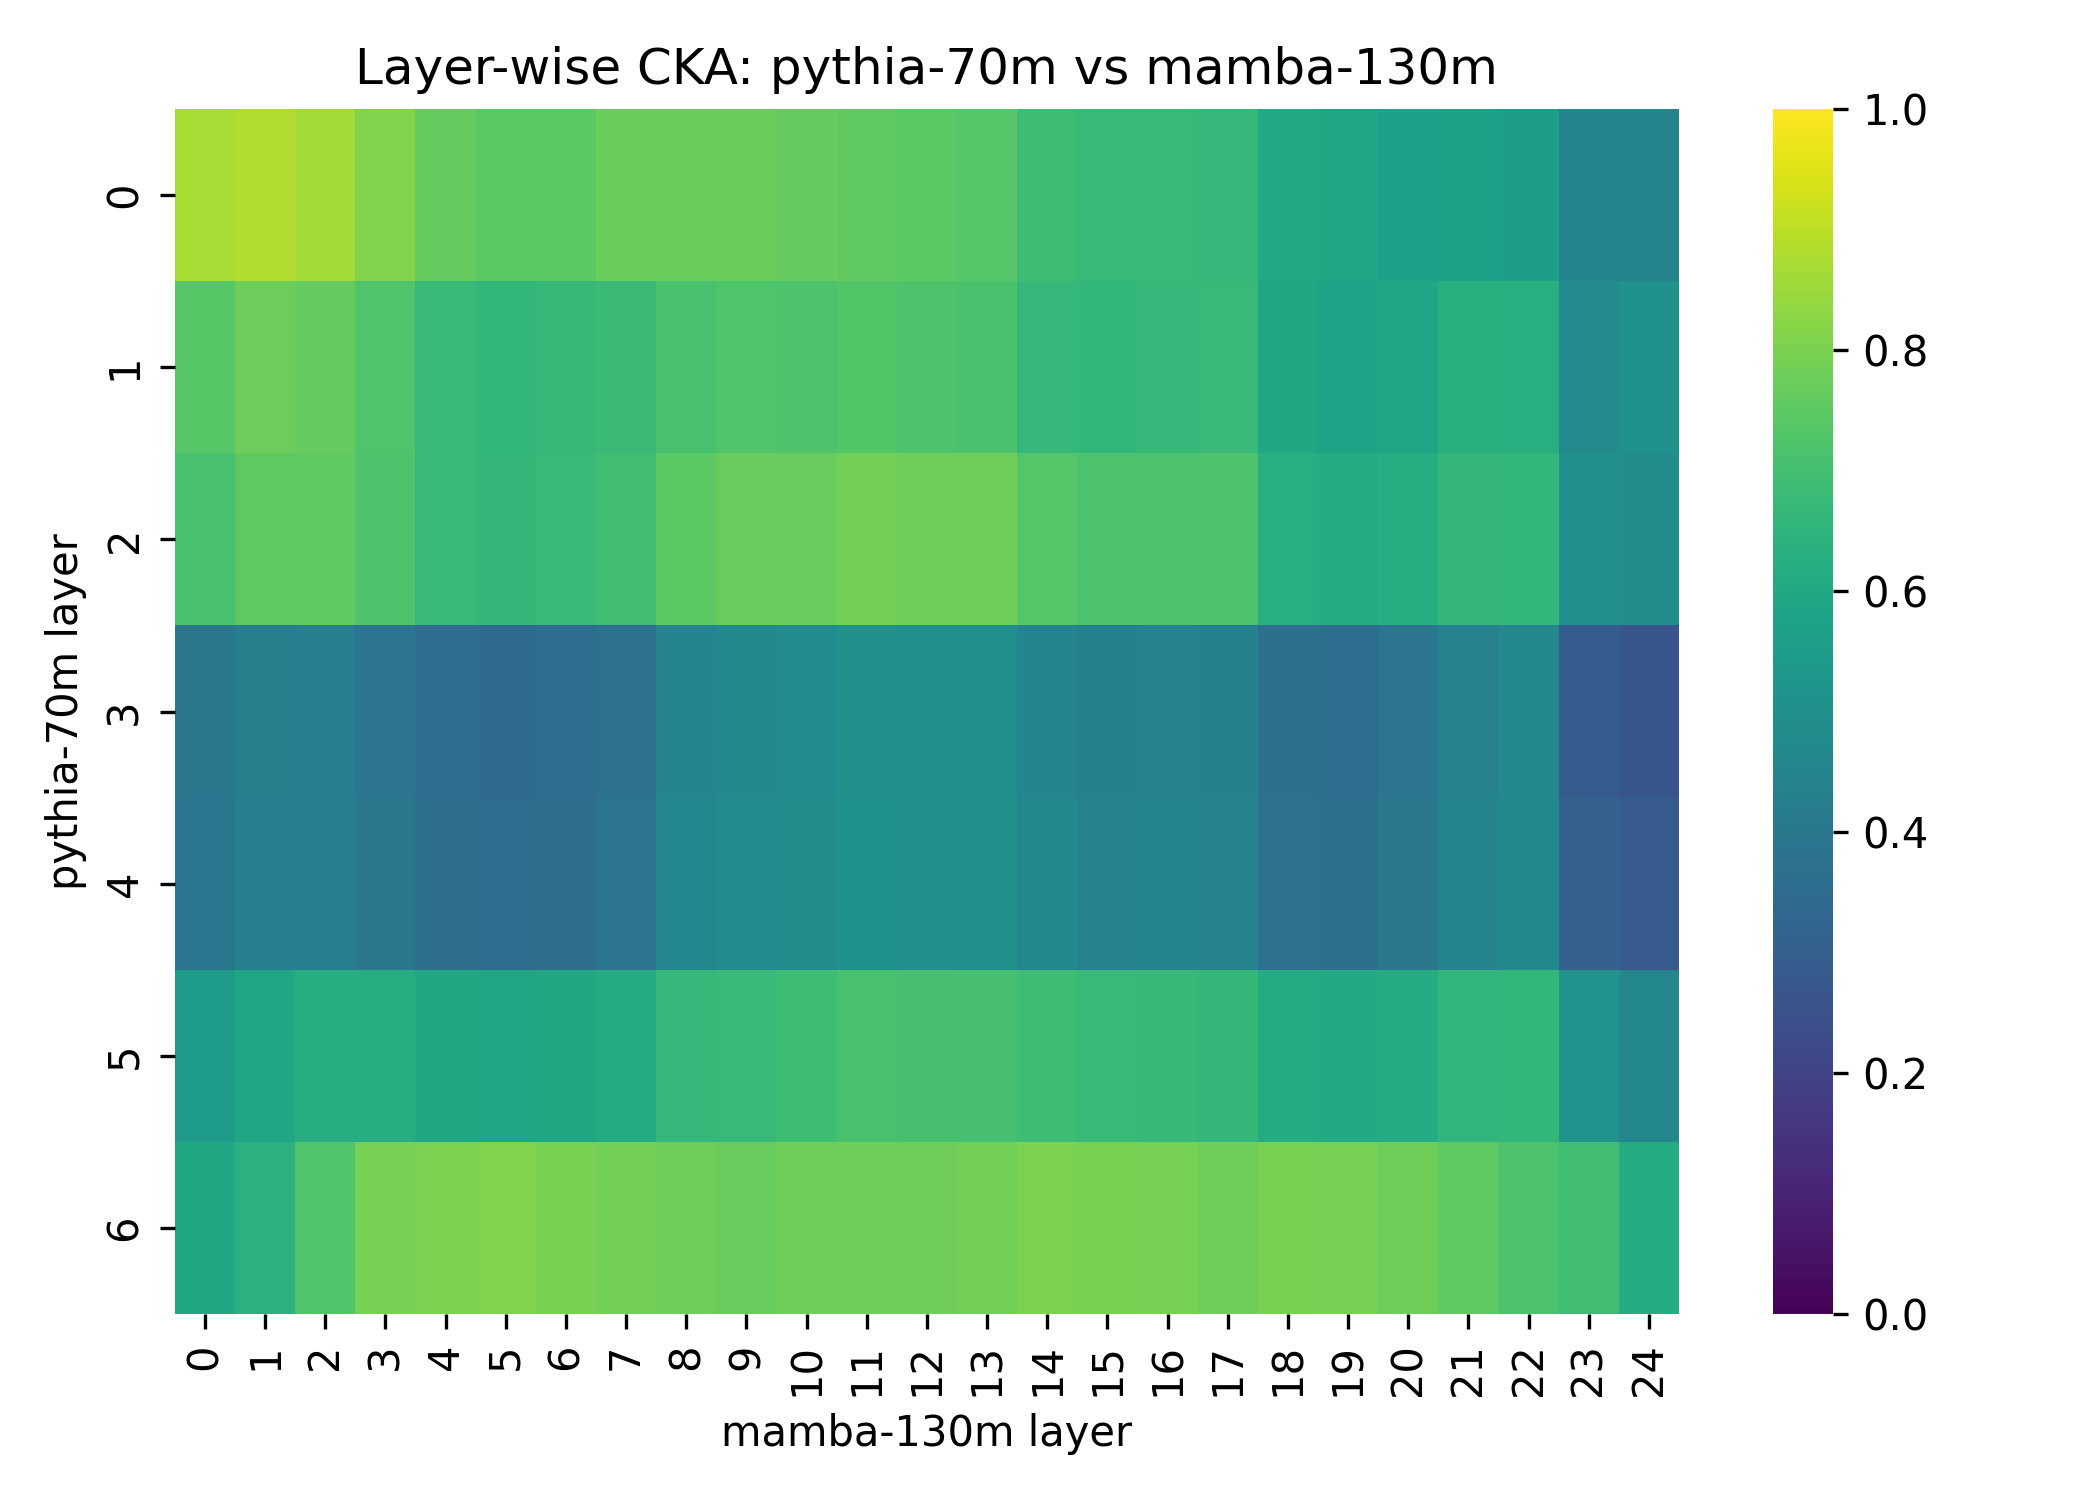

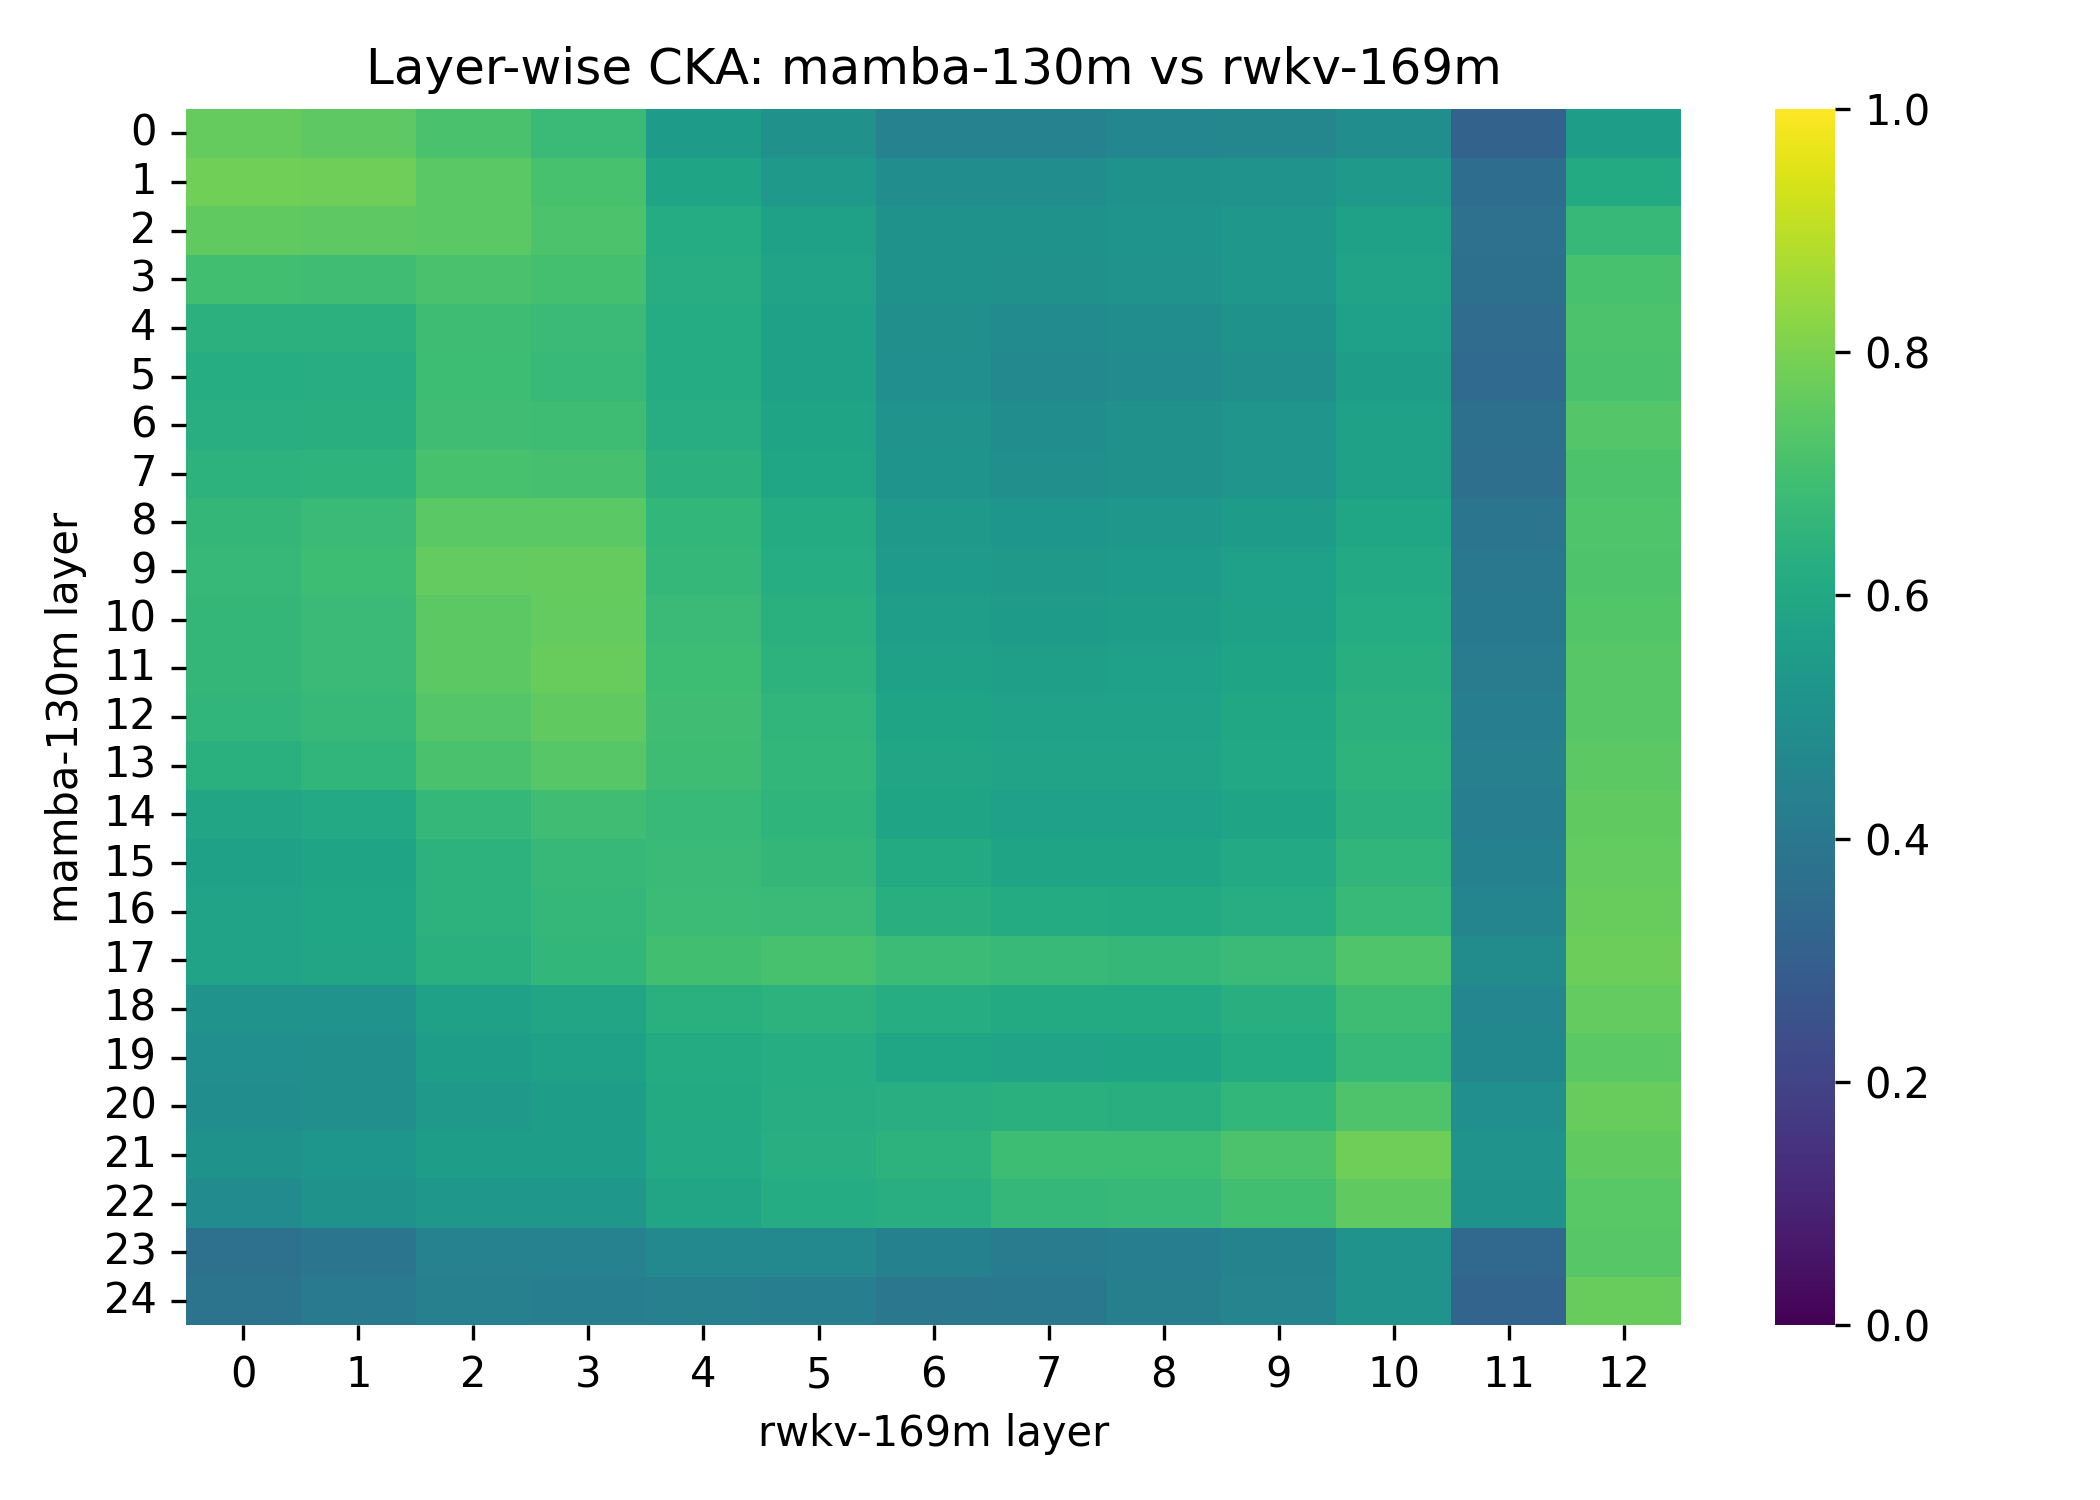

In [4]:
display(Image(filename=FIGURES_DIR / "cka_pythia-70m_vs_mamba-130m.png", width=520))
display(Image(filename=FIGURES_DIR / "cka_mamba-130m_vs_rwkv-169m.png", width=520))

## Baseline and neighborhood comparison

The shuffled-text baseline preserves each model's representation distribution but breaks example-level correspondence. Real model pairs show much higher CKA than the shuffled baseline

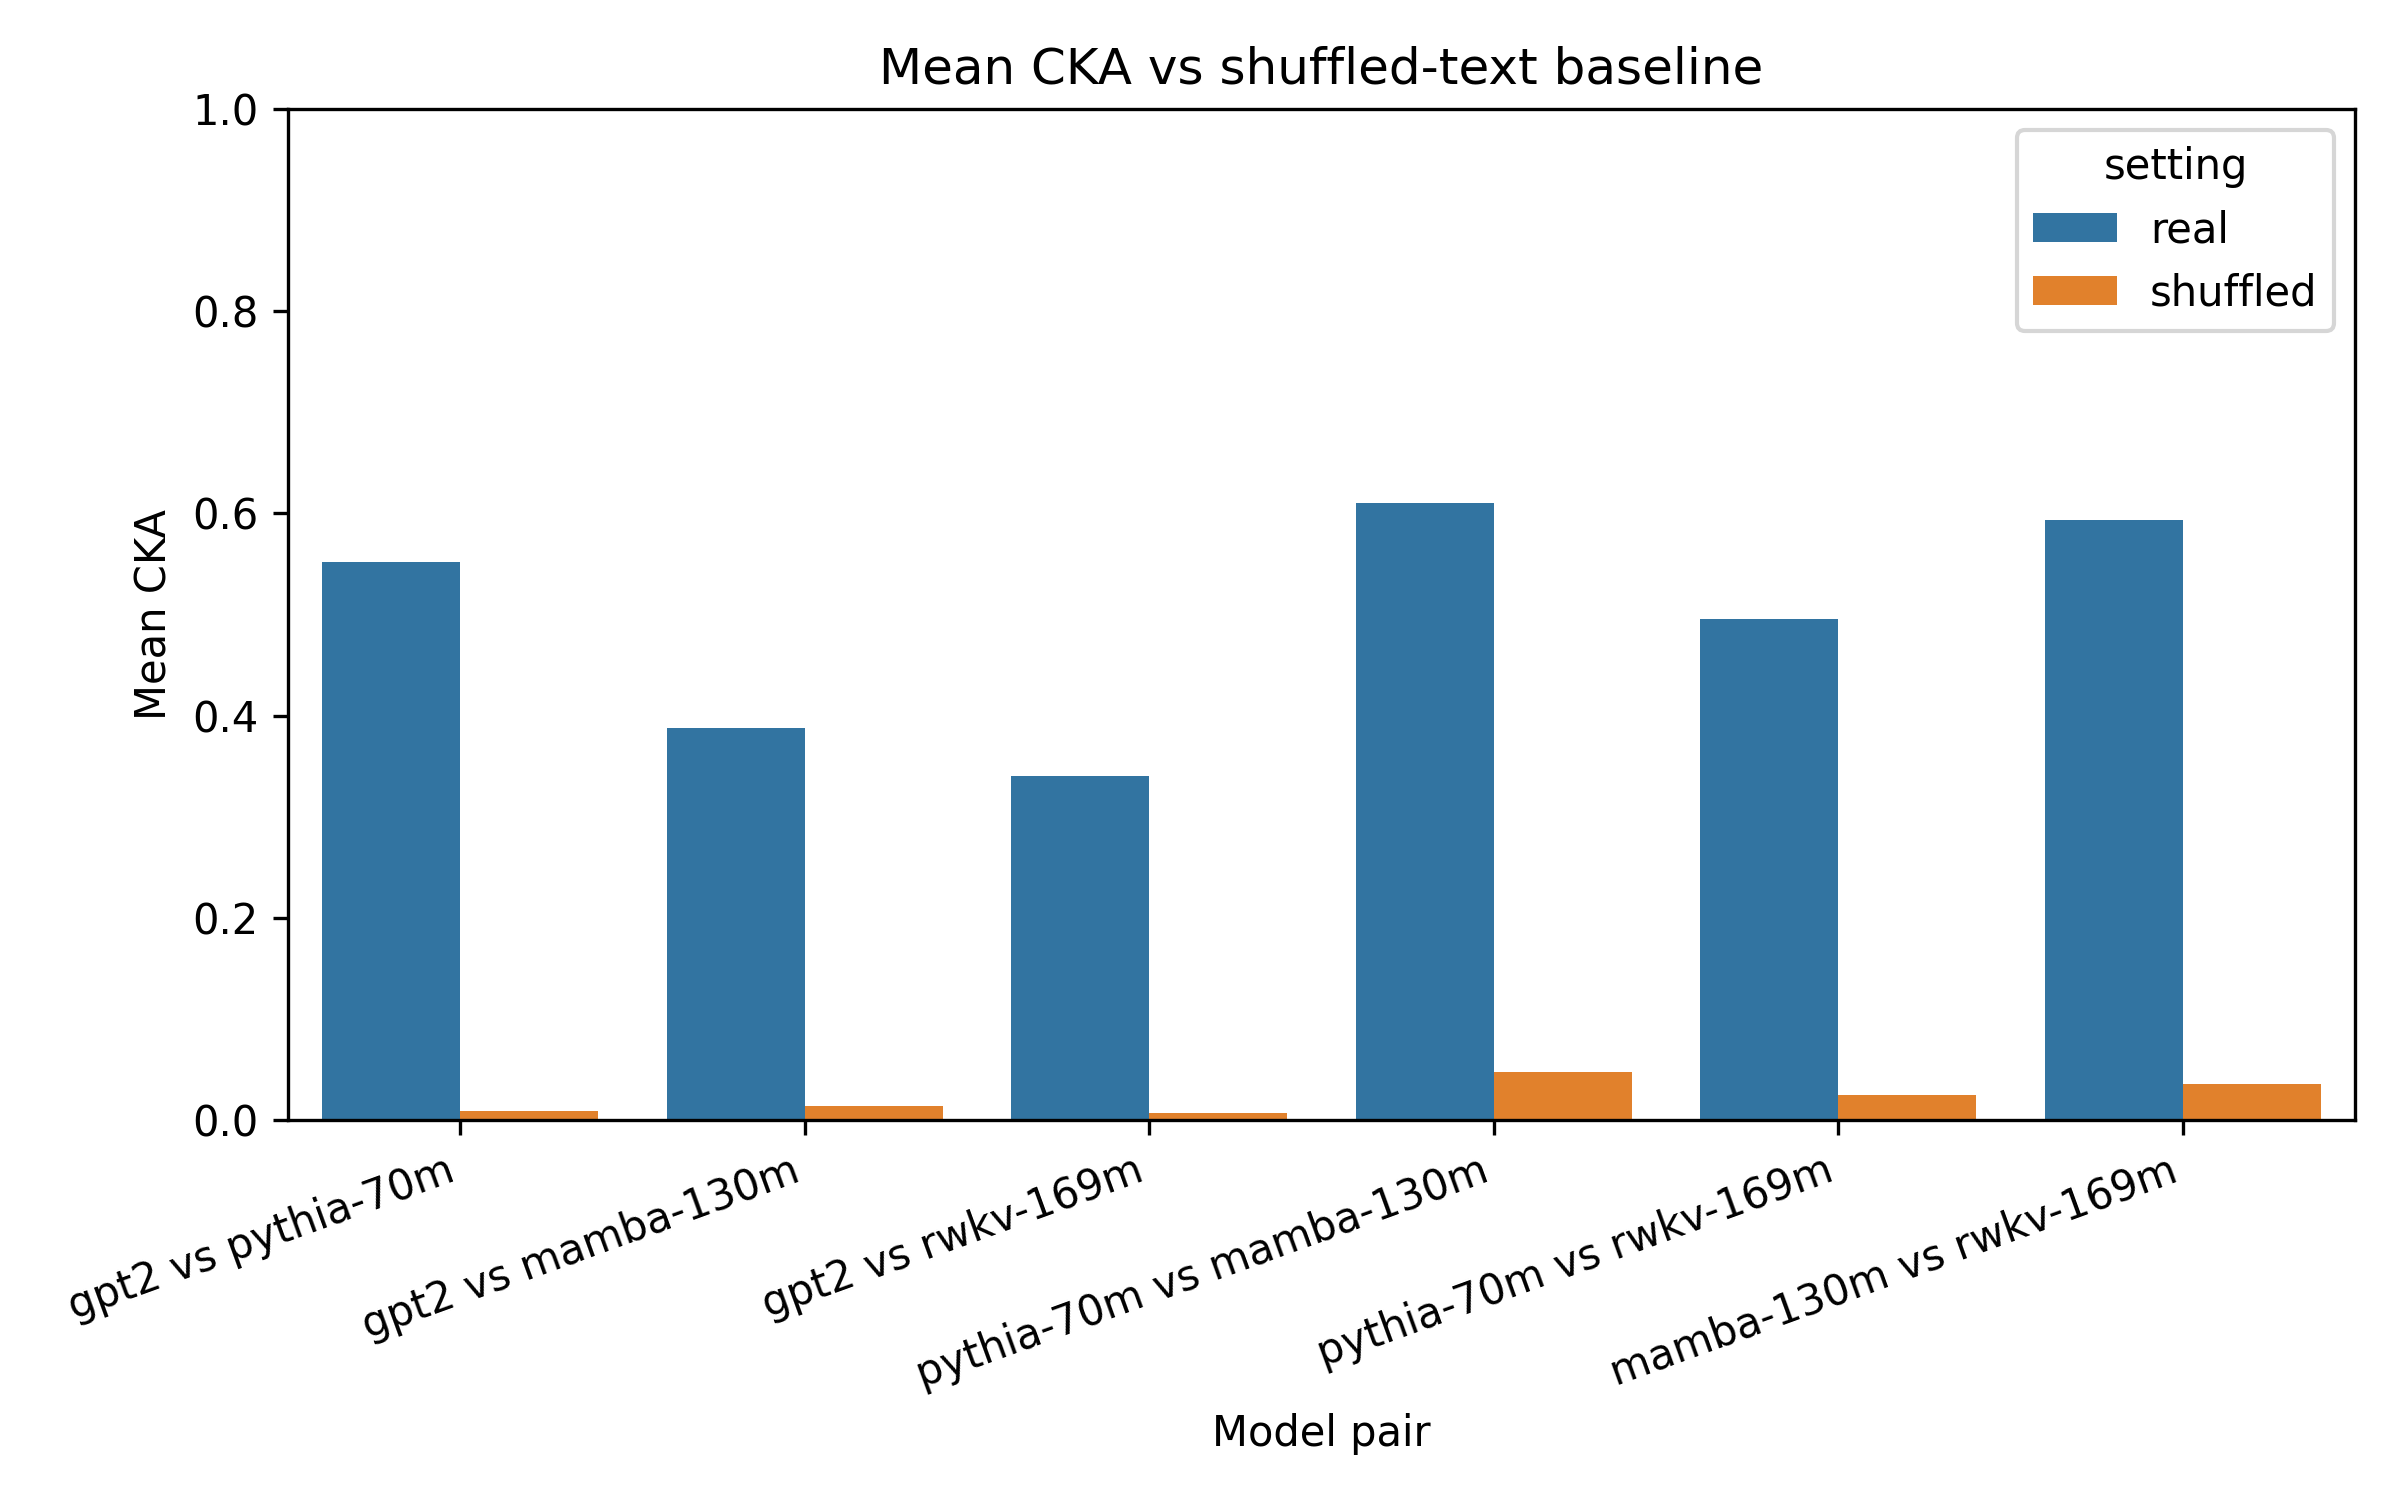

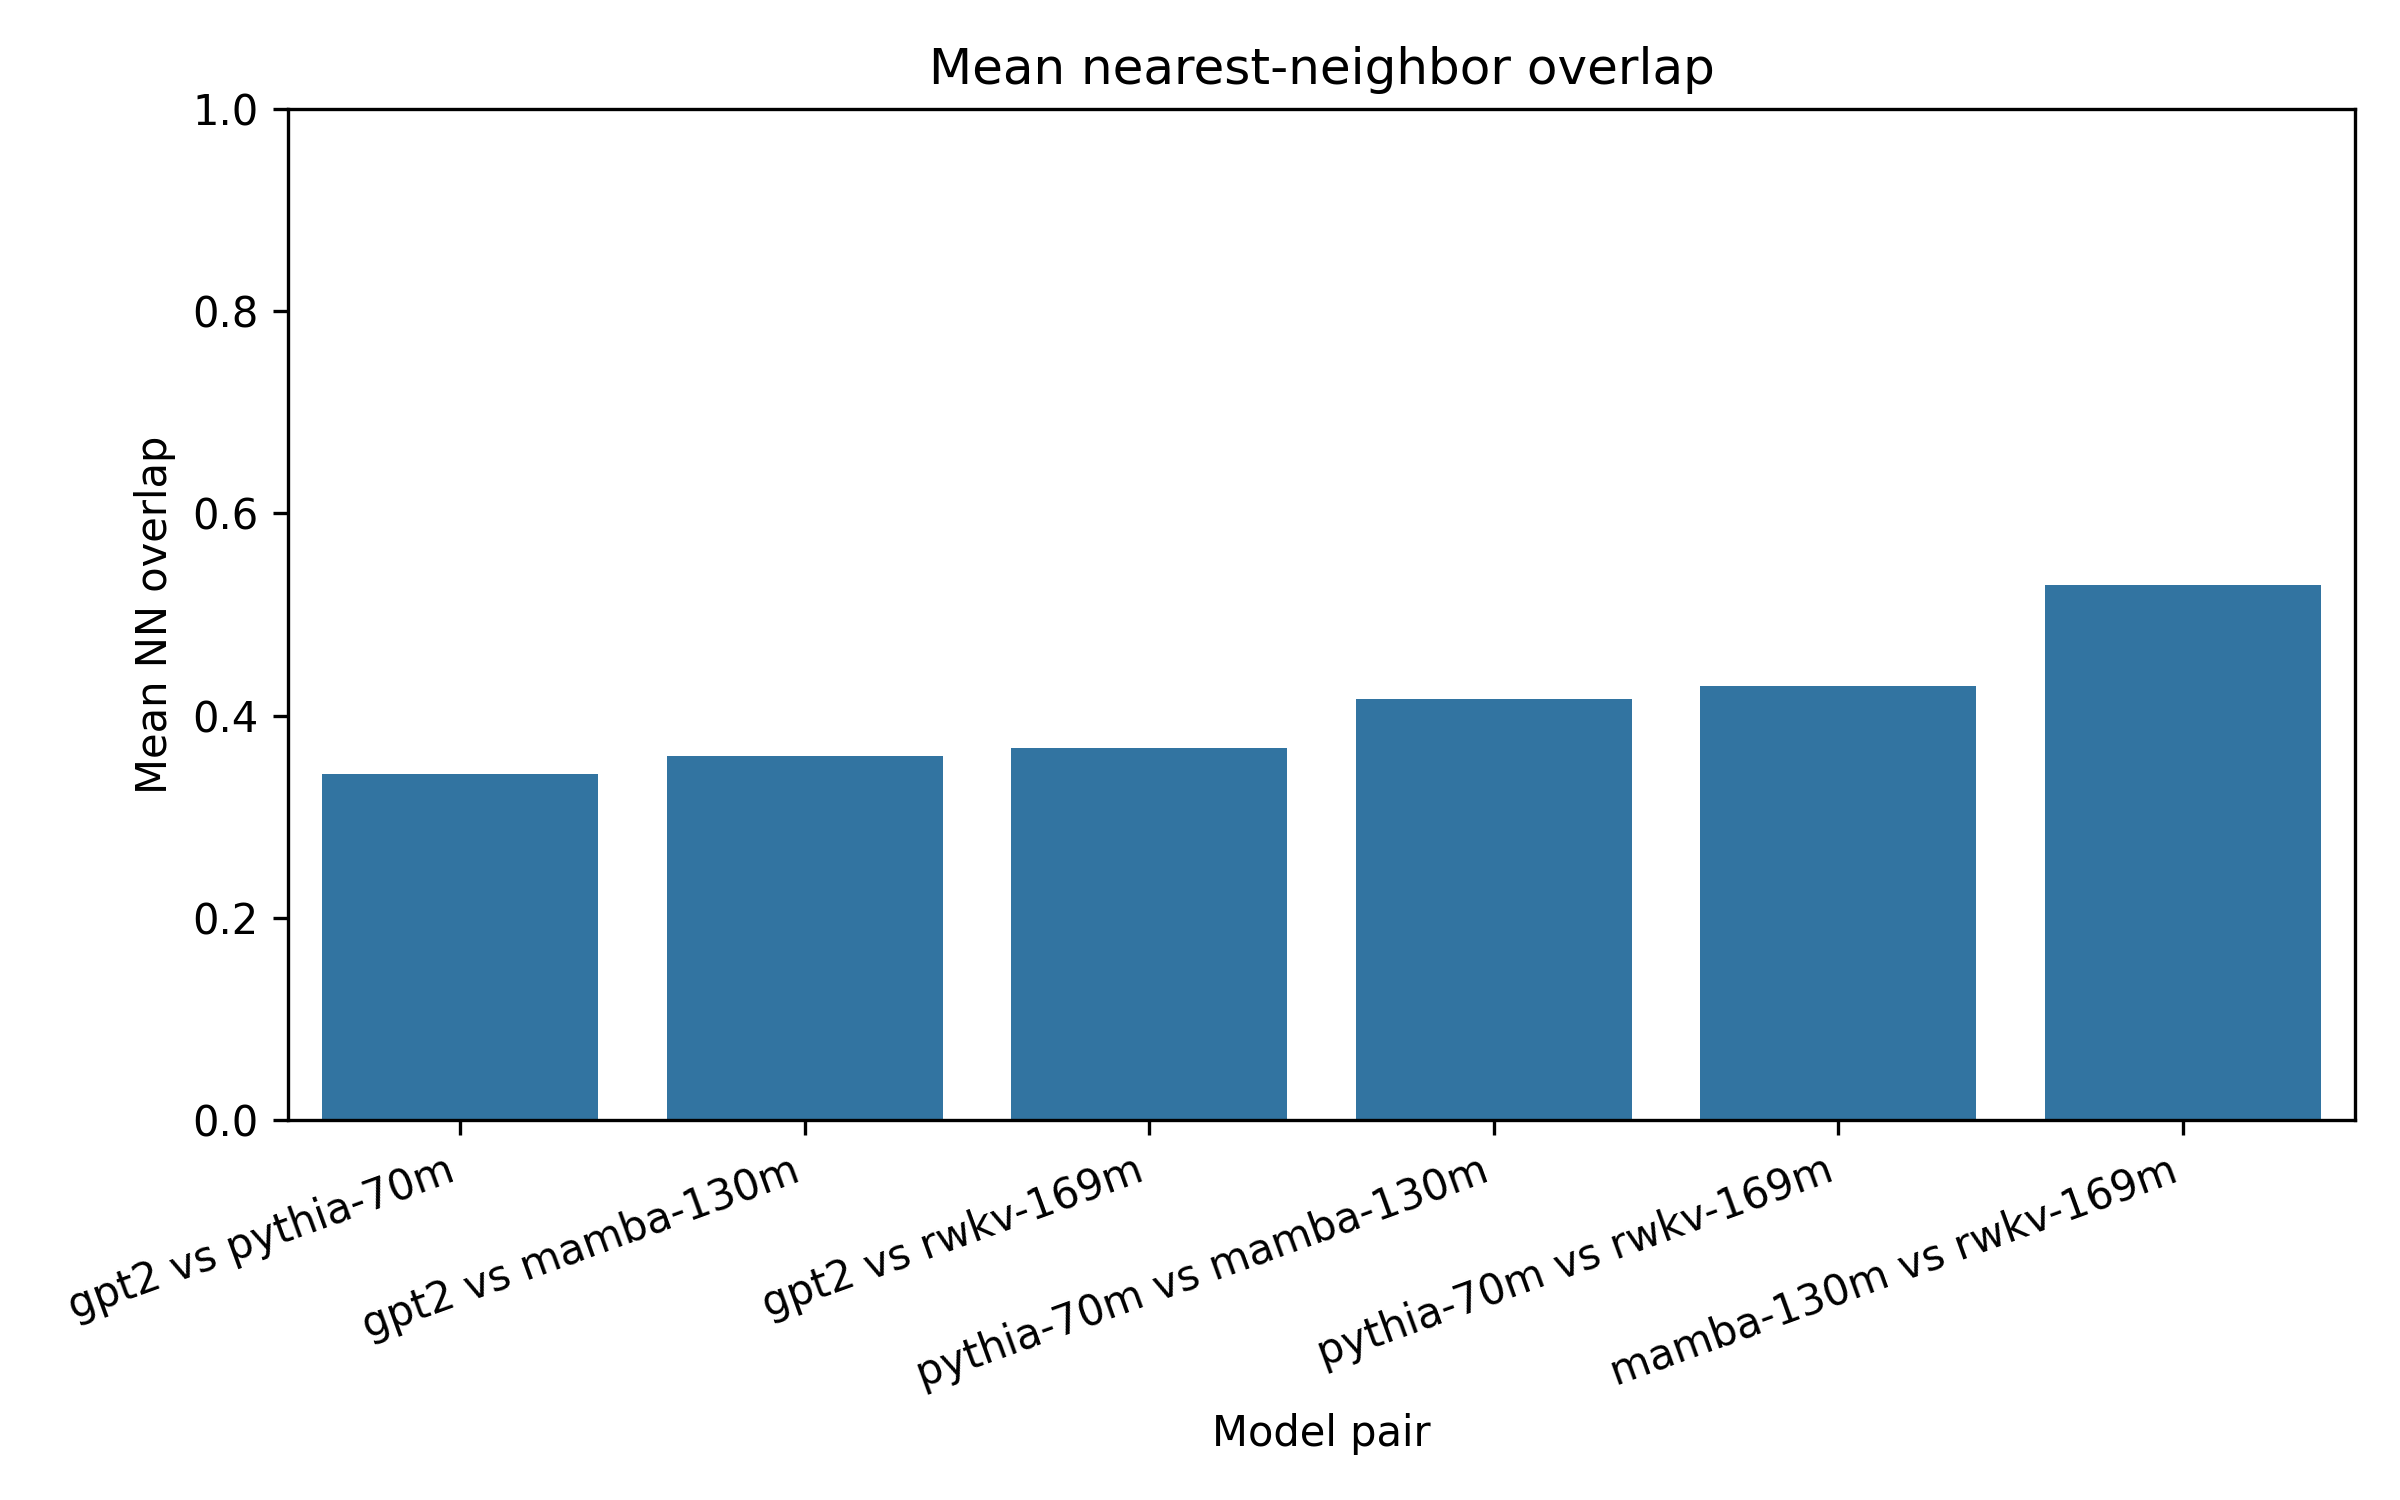

In [5]:
display(Image(filename=FIGURES_DIR / "baseline_comparison.png", width=620))
display(Image(filename=FIGURES_DIR / "nn_overlap_comparison.png", width=620))

## Qualitative visualization

UMAP provides a qualitative view of final-layer sentence representations. This visualization is used as supporting evidence; the main quantitative evidence comes from CKA, nearest-neighbor overlap, and the shuffled-text baseline

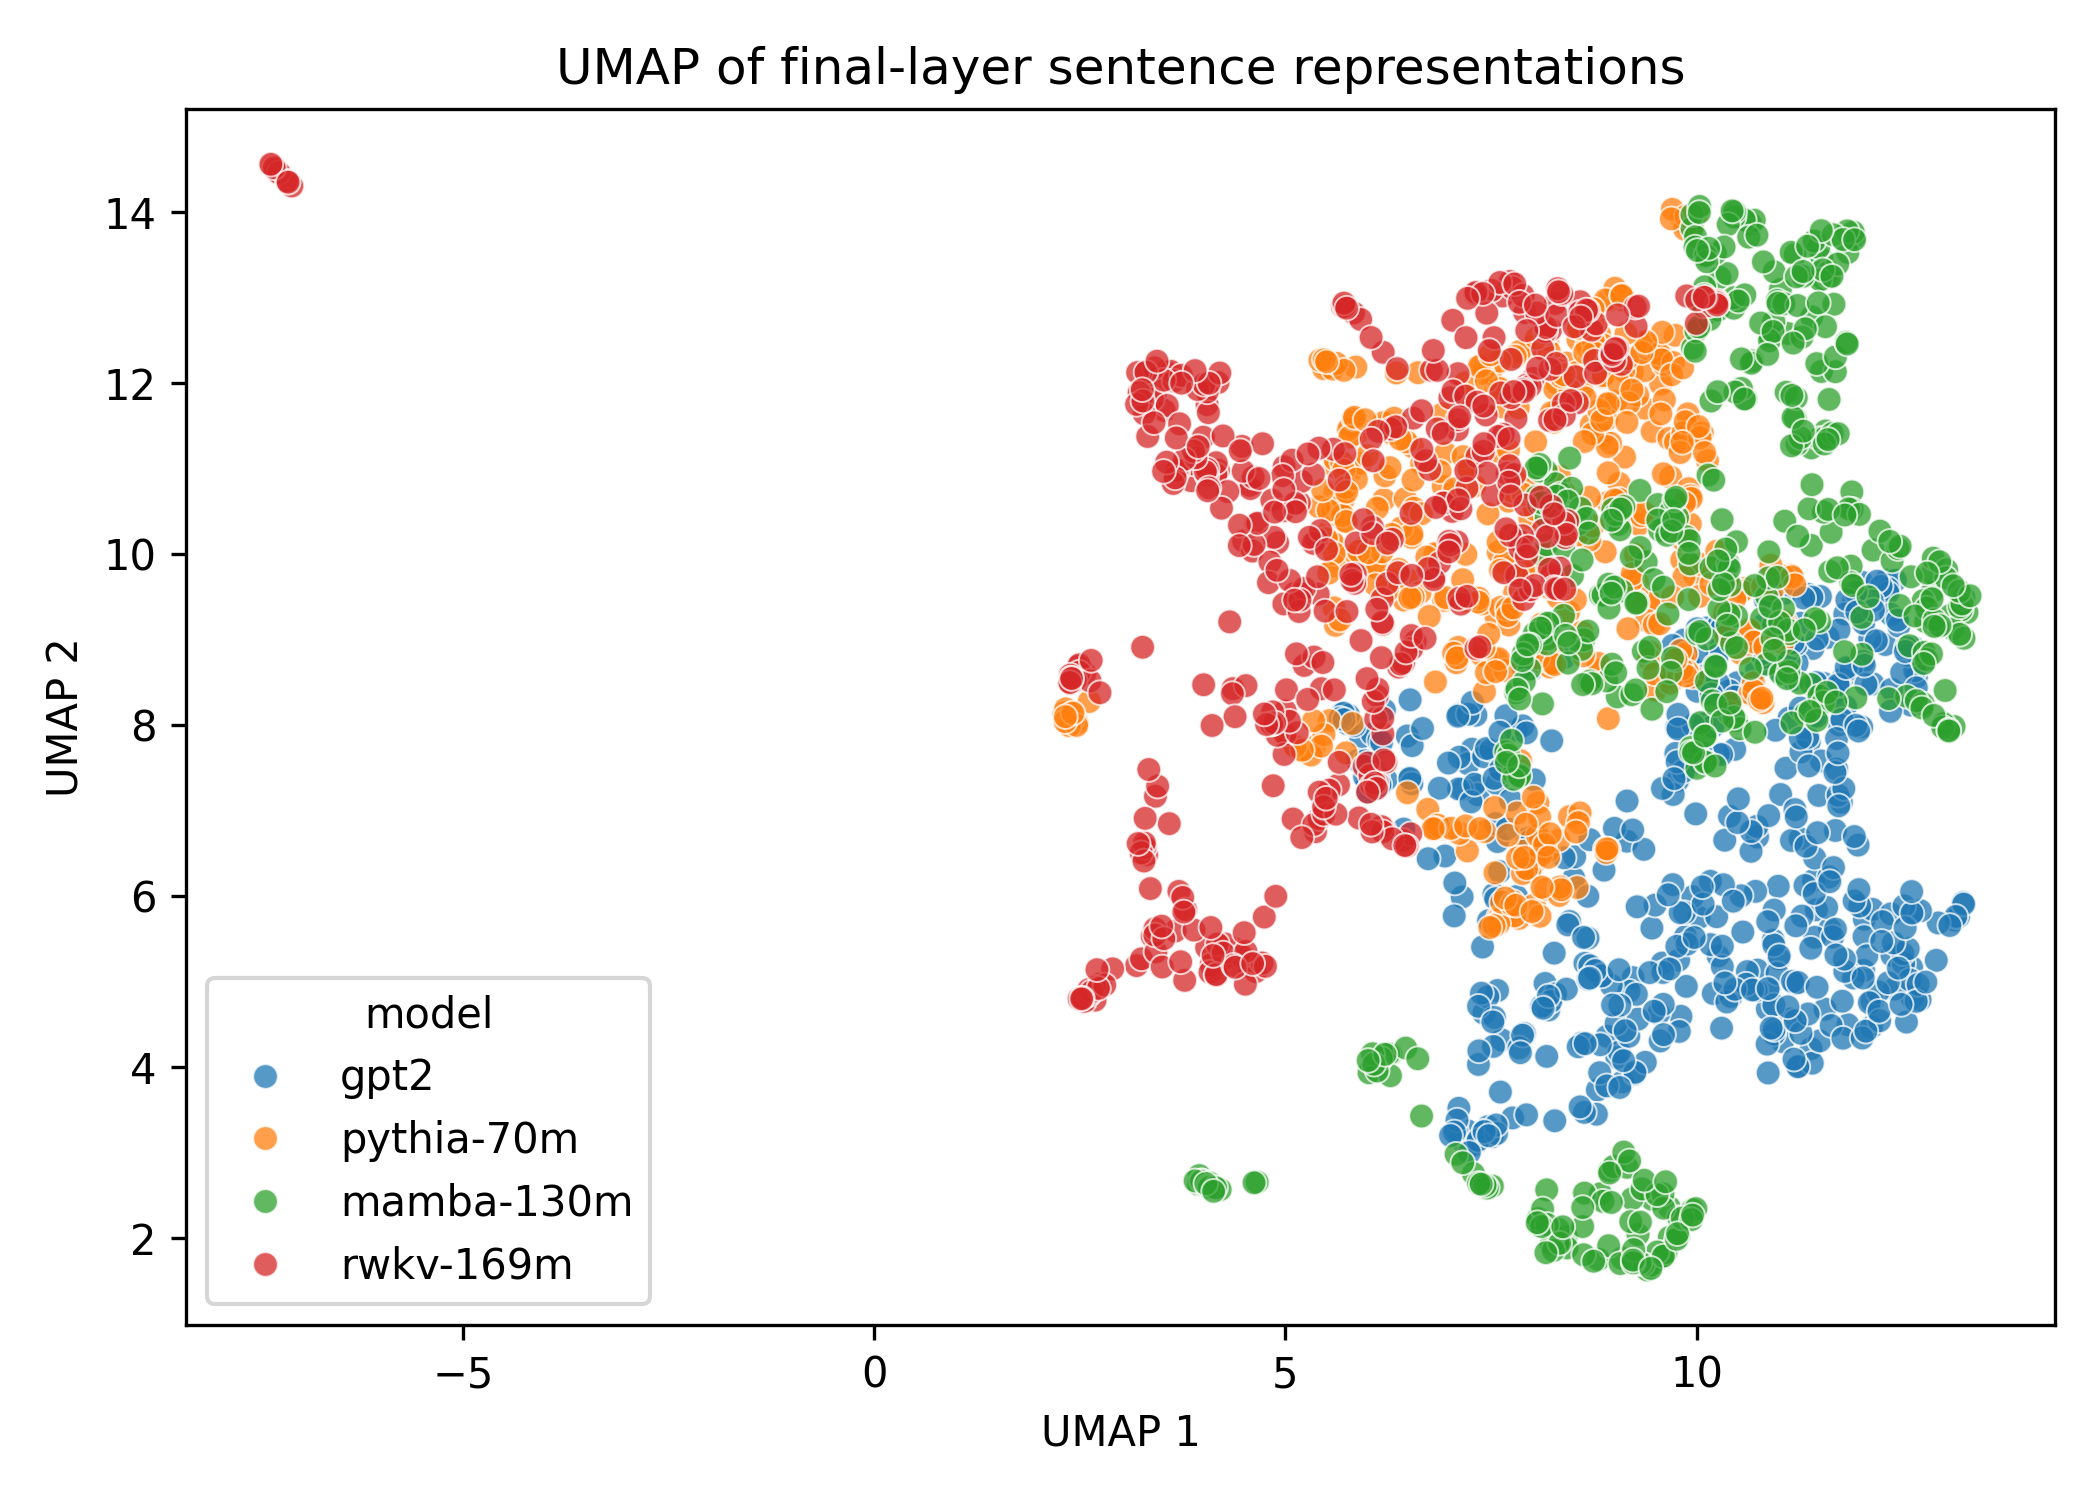

In [6]:
display(Image(filename=FIGURES_DIR / "umap_final_layers.png", width=620))